<a href="https://colab.research.google.com/github/sibasishsahu68/AML-Lab/blob/main/Experiment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Summary ---
Shape: (100, 5)

Missing Values:
 SEM 1    0
SEM 2    0
SEM 3    0
SEM 4    0
SEM 5    0
dtype: int64

Stats:
             SEM 1       SEM 2       SEM 3       SEM 4       SEM 5
count  100.000000  100.000000  100.000000  100.000000  100.000000
mean    75.990000   74.400000   77.120000   75.900000   77.960000
std     14.577896   14.511577   14.522209   14.249225   14.571953
min     50.000000   50.000000   50.000000   50.000000   51.000000
25%     64.750000   63.000000   63.500000   63.750000   65.750000
50%     75.500000   71.500000   81.500000   76.000000   79.000000
75%     90.000000   87.250000   89.250000   88.000000   92.000000
max     98.000000   99.000000   99.000000   98.000000   99.000000


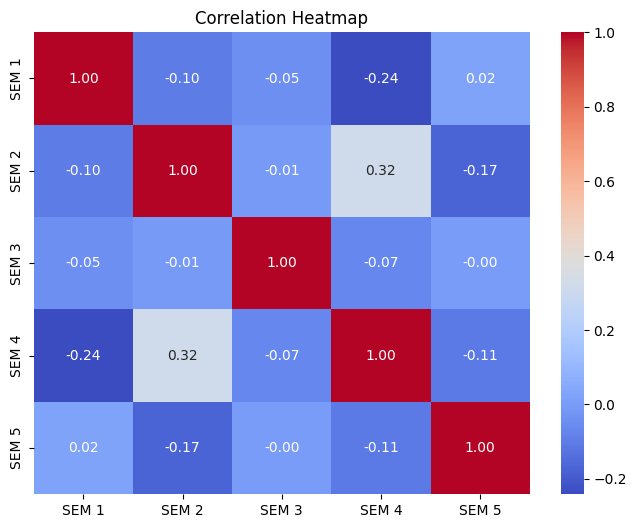

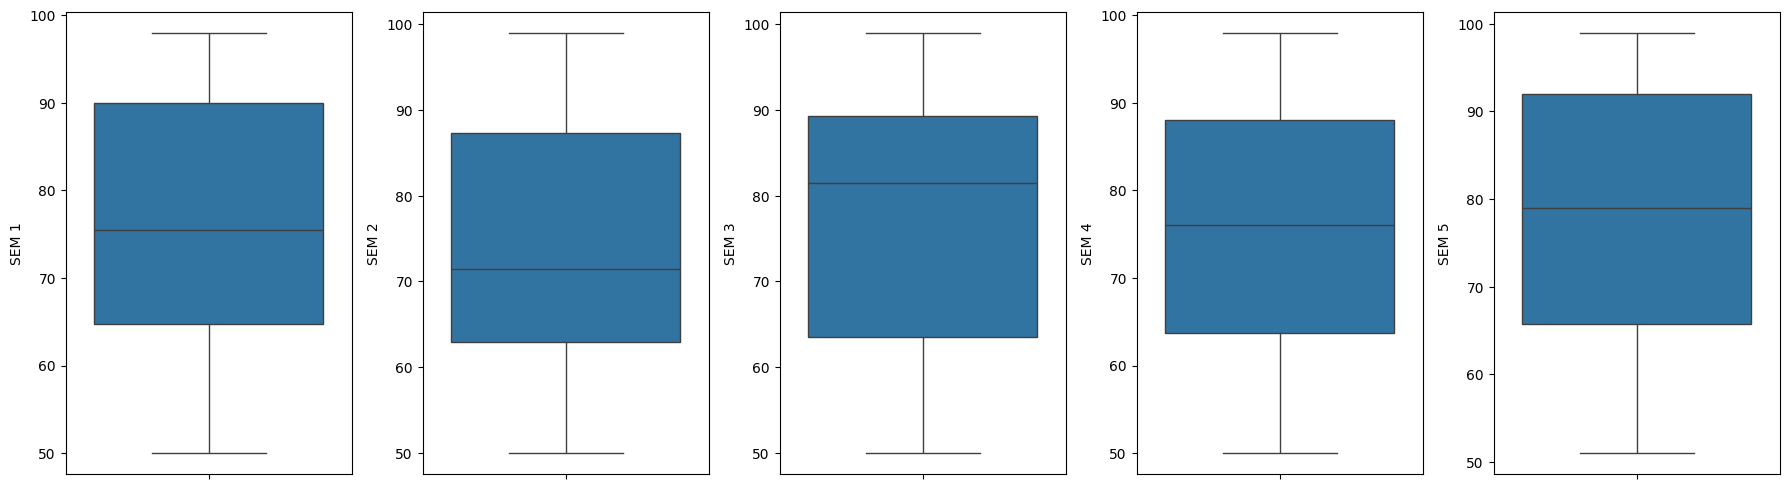


Top correlated feature with SEM 5 is: 'SEM 2'

--- Simple Linear Regression ---
Equation: y = 92.4427 + -0.1939 * SEM 2
MSE: 249.2164 | MAE: 14.6306 | RMSE: 15.7866 | R²: 0.0039


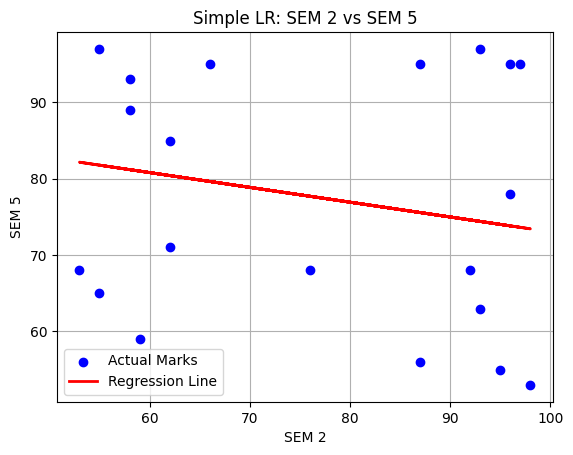

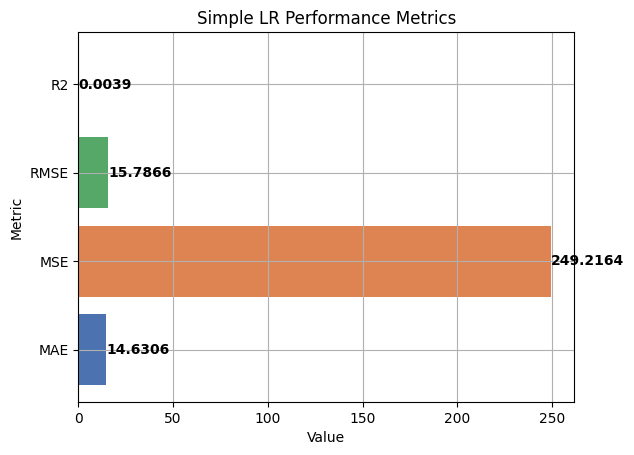


--- Multiple Linear Regression ---
Equation: y = 91.4541 + -0.0427 * SEM 1 + -0.2228 * SEM 2 + 0.0106 * SEM 3 + 0.0738 * SEM 4
MSE: 272.8025 | MAE: 15.2866 | RMSE: 16.5167 | R²: -0.0904


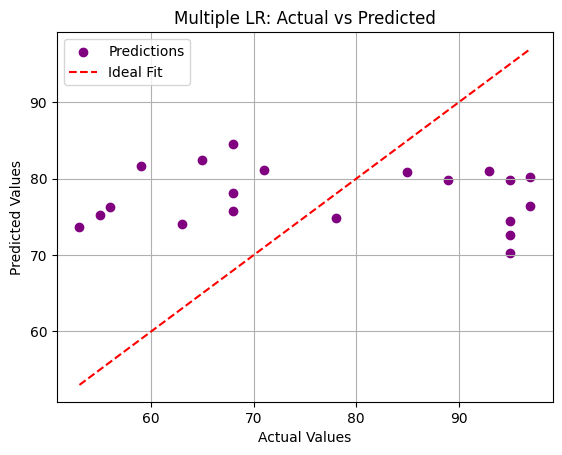

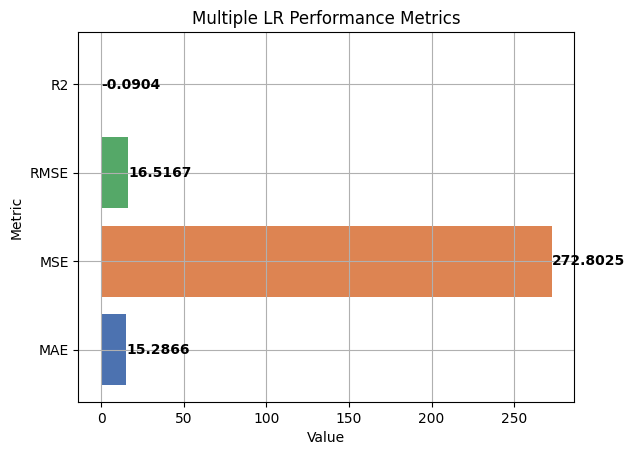


--- Enter Marks to Predict SEM 5 ---
Enter 1st Semester marks: 78
Enter 2nd Semester marks: 56
Enter 3rd Semester marks: 54
Enter 4th Semester marks: 54

The predicted 5th Semester mark is: 80.20


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def train_and_evaluate(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    equation = f"y = {model.intercept_:.4f}"
    for coef, col in zip(model.coef_, X.columns):
        equation += f" + {coef:.4f} * {col}"
    print(f"\n--- {title} ---")
    print(f"Equation: {equation}")
    print(f"MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
    return model, X_test, y_test, predictions, [mae, mse, rmse, r2]


def plot_chart(chart_type, x_data, y_data, title, xlabel, ylabel, predictions=None):
    if chart_type == 'scatter_line':
        plt.scatter(x_data, y_data, color='blue', label='Actual Marks')
        plt.plot(x_data, predictions, color='red', linewidth=2, label='Regression Line')
        plt.legend()
    elif chart_type == 'actual_vs_pred':
        plt.scatter(x_data, y_data, color='purple', label='Predictions')
        plt.plot([x_data.min(), x_data.max()], [x_data.min(), x_data.max()], 'r--', label='Ideal Fit')
        plt.legend()
    elif chart_type == 'metrics_bar':
        bars = plt.barh(["MAE", "MSE", "RMSE", "R2"], x_data, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
        for bar in bars:
            width = bar.get_width()
            plt.annotate(f"{width:.4f}", xy=(width, bar.get_y() + bar.get_height() / 2), ha="left", va="center", fontweight="bold")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()


# Placeholder for loading data, replace with your actual data loading method
# Example: data = pd.read_csv('your_dataset.csv')
# For demonstration, creating a dummy dataframe with SEM 1 to SEM 5 columns
data = pd.DataFrame({
    'SEM 1': np.random.randint(50, 100, 100),
    'SEM 2': np.random.randint(50, 100, 100),
    'SEM 3': np.random.randint(50, 100, 100),
    'SEM 4': np.random.randint(50, 100, 100),
    'SEM 5': np.random.randint(50, 100, 100)
})


print("--- Dataset Summary ---")
print("Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())
print("\nStats:\n", data.describe())

features = ['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4']
X_all = data[features]
y = data['SEM 5']

plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

fig, axes = plt.subplots(1, len(data.columns), figsize=(18, 5))
for i, col in enumerate(data.columns):
    sns.boxplot(y=data[col], ax=axes[i])
plt.tight_layout()
plt.show()

best_feature = X_all.corrwith(y).abs().idxmax()
print(f"\nTop correlated feature with SEM 5 is: '{best_feature}'")

X_simple = data[[best_feature]]
simple_model, X_test_s, y_test_s, pred_s, metrics_s = train_and_evaluate(X_simple, y, 'Simple Linear Regression')

plot_chart('scatter_line', X_test_s, y_test_s, f'Simple LR: {best_feature} vs SEM 5', best_feature, 'SEM 5', pred_s)
plot_chart('metrics_bar', metrics_s, None, 'Simple LR Performance Metrics', 'Value', 'Metric')

multi_model, X_test_m, y_test_m, pred_m, metrics_m = train_and_evaluate(X_all, y, 'Multiple Linear Regression')

plot_chart('actual_vs_pred', y_test_m, pred_m, 'Multiple LR: Actual vs Predicted', 'Actual Values', 'Predicted Values')
plot_chart('metrics_bar', metrics_m, None, 'Multiple LR Performance Metrics', 'Value', 'Metric')

print("\n--- Enter Marks to Predict SEM 5 ---")
s1 = float(input("Enter 1st Semester marks: "))
s2 = float(input("Enter 2nd Semester marks: "))
s3 = float(input("Enter 3rd Semester marks: "))
s4 = float(input("Enter 4th Semester marks: "))

user_input = pd.DataFrame([{"SEM 1": s1, "SEM 2": s2, "SEM 3": s3, "SEM 4": s4}])
predicted_mark = multi_model.predict(user_input)[0]
print(f"\nThe predicted 5th Semester mark is: {predicted_mark:.2f}")